In [24]:
import pandas as pd

# Load original data
df = pd.read_csv('../data/raw/german_credit.csv')

# Rename columns
feature_names = {
    'Attribute1':  'checking_account',
    'Attribute2':  'duration_months',
    'Attribute3':  'credit_history',
    'Attribute4':  'purpose',
    'Attribute5':  'credit_amount',
    'Attribute6':  'savings_account',
    'Attribute7':  'employment_years',
    'Attribute8':  'installment_rate',
    'Attribute9':  'personal_status',
    'Attribute10': 'other_debtors',
    'Attribute11': 'residence_years',
    'Attribute12': 'property',
    'Attribute13': 'age',
    'Attribute14': 'other_installments',
    'Attribute15': 'housing',
    'Attribute16': 'existing_credits',
    'Attribute17': 'job',
    'Attribute18': 'num_dependents',
    'Attribute19': 'telephone',
    'Attribute20': 'foreign_worker',
}

df = df.rename(columns=feature_names)

# Save BOTH files again with new names
df.to_csv('../data/raw/german_credit.csv', index=False)
df.to_csv('../data/processed/german_credit_encoded.csv', index=False)

print("Both files re-saved with new column names:")
print(list(df.columns))

Both files re-saved with new column names:
['checking_account', 'duration_months', 'credit_history', 'purpose', 'credit_amount', 'savings_account', 'employment_years', 'installment_rate', 'personal_status', 'other_debtors', 'residence_years', 'property', 'age', 'other_installments', 'housing', 'existing_credits', 'job', 'num_dependents', 'telephone', 'foreign_worker', 'credit_risk']


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Load saved dataset
df = pd.read_csv('../data/raw/german_credit.csv')

# Separate features and target
X = df.drop('credit_risk', axis=1)
y = df['credit_risk']

# Identify feature types
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical: {len(cat_cols)} features")
print(f"Numerical:   {len(num_cols)} features")
print(f"Target:      {y.value_counts().to_dict()}")

Categorical: 13 features
Numerical:   7 features
Target:      {0: 700, 1: 300}


In [27]:
# Label encode all categorical features
# (LabelEncoder for tree-based models — they handle ordinal encoding well)
le_dict = {}
X_encoded = X.copy()

for col in cat_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])
    le_dict[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print(f"\nEncoded shape: {X_encoded.shape}")
print(f"All dtypes now numeric: {X_encoded.dtypes.value_counts().to_dict()}")
print(f"\nFirst 3 rows after encoding:")
X_encoded.head(3)

checking_account: {'A11': np.int64(0), 'A12': np.int64(1), 'A13': np.int64(2), 'A14': np.int64(3)}
credit_history: {'A30': np.int64(0), 'A31': np.int64(1), 'A32': np.int64(2), 'A33': np.int64(3), 'A34': np.int64(4)}
purpose: {'A40': np.int64(0), 'A41': np.int64(1), 'A410': np.int64(2), 'A42': np.int64(3), 'A43': np.int64(4), 'A44': np.int64(5), 'A45': np.int64(6), 'A46': np.int64(7), 'A48': np.int64(8), 'A49': np.int64(9)}
savings_account: {'A61': np.int64(0), 'A62': np.int64(1), 'A63': np.int64(2), 'A64': np.int64(3), 'A65': np.int64(4)}
employment_years: {'A71': np.int64(0), 'A72': np.int64(1), 'A73': np.int64(2), 'A74': np.int64(3), 'A75': np.int64(4)}
personal_status: {'A91': np.int64(0), 'A92': np.int64(1), 'A93': np.int64(2), 'A94': np.int64(3)}
other_debtors: {'A101': np.int64(0), 'A102': np.int64(1), 'A103': np.int64(2)}
property: {'A121': np.int64(0), 'A122': np.int64(1), 'A123': np.int64(2), 'A124': np.int64(3)}
other_installments: {'A141': np.int64(0), 'A142': np.int64(1), '

,checking_account,duration_months,credit_history,purpose,credit_amount,savings_account,employment_years,installment_rate,personal_status,other_debtors,residence_years,property,age,other_installments,housing,existing_credits,job,num_dependents,telephone,foreign_worker
0,0,6,4,4,1169,4,4,4,2,0,4,0,67,2,1,2,2,1,1,0
1,1,48,2,4,5951,0,2,2,1,0,2,0,22,2,1,1,2,1,0,0
2,3,12,4,7,2096,0,3,2,2,0,3,0,49,2,1,1,1,2,0,0


In [28]:
import os
os.makedirs('../data/processed', exist_ok=True)

# Save encoded features + target
df_encoded = X_encoded.copy()
df_encoded['credit_risk'] = y.values
df_encoded.to_csv('../data/processed/german_credit_encoded.csv', index=False)

print(f"Saved encoded dataset: {df_encoded.shape}")
print(f"Location: data/processed/german_credit_encoded.csv")

Saved encoded dataset: (1000, 21)
Location: data/processed/german_credit_encoded.csv


In [29]:
# Train/test split — 80/20 stratified by target
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print("BEFORE SMOTE:")
print(f"  Training set: {X_train.shape[0]} samples")
print(f"    Good (0): {(y_train==0).sum()} ({(y_train==0).mean():.1%})")
print(f"    Bad  (1): {(y_train==1).sum()} ({(y_train==1).mean():.1%})")
print(f"  Test set:     {X_test.shape[0]} samples")
print(f"    Good (0): {(y_test==0).sum()} ({(y_test==0).mean():.1%})")
print(f"    Bad  (1): {(y_test==1).sum()} ({(y_test==1).mean():.1%})")

BEFORE SMOTE:
  Training set: 800 samples
    Good (0): 560 (70.0%)
    Bad  (1): 240 (30.0%)
  Test set:     200 samples
    Good (0): 140 (70.0%)
    Bad  (1): 60 (30.0%)


In [30]:
# Apply SMOTE to training data ONLY
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("AFTER SMOTE (training set only):")
print(f"  Training set: {X_train_smote.shape[0]} samples")
print(f"    Good (0): {(y_train_smote==0).sum()} ({(y_train_smote==0).mean():.1%})")
print(f"    Bad  (1): {(y_train_smote==1).sum()} ({(y_train_smote==1).mean():.1%})")
print(f"  Test set:     {X_test.shape[0]} samples (UNCHANGED)")
print(f"    Good (0): {(y_test==0).sum()}")
print(f"    Bad  (1): {(y_test==1).sum()}")
print(f"\n✓ SMOTE applied to training set only — no data leakage")

AFTER SMOTE (training set only):
  Training set: 1120 samples
    Good (0): 560 (50.0%)
    Bad  (1): 560 (50.0%)
  Test set:     200 samples (UNCHANGED)
    Good (0): 140
    Bad  (1): 60

✓ SMOTE applied to training set only — no data leakage


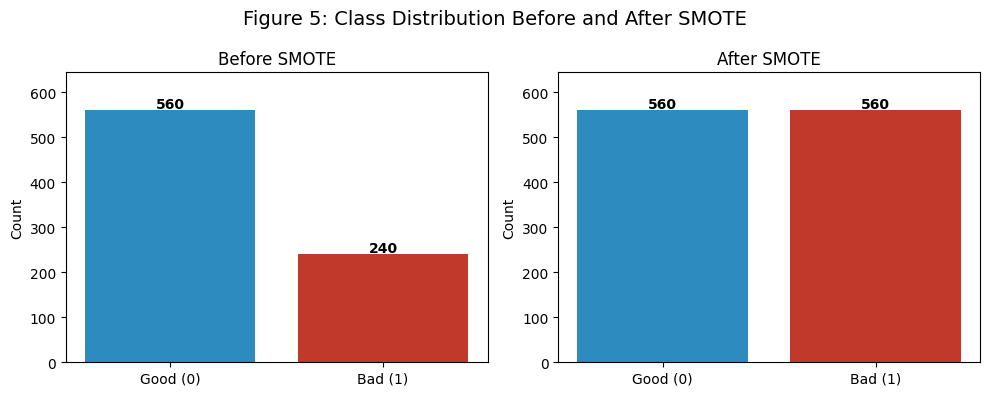

In [31]:
# Before/after SMOTE comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Before
counts_before = y_train.value_counts()
ax1.bar(['Good (0)', 'Bad (1)'], counts_before.values, color=['#2E8BC0', '#C0392B'])
for i, v in enumerate(counts_before.values):
    ax1.text(i, v+5, str(v), ha='center', fontweight='bold')
ax1.set_title('Before SMOTE')
ax1.set_ylabel('Count')
ax1.set_ylim(0, max(counts_before.values)*1.15)

# After
counts_after = pd.Series(y_train_smote).value_counts()
ax2.bar(['Good (0)', 'Bad (1)'], counts_after.values, color=['#2E8BC0', '#C0392B'])
for i, v in enumerate(counts_after.values):
    ax2.text(i, v+5, str(v), ha='center', fontweight='bold')
ax2.set_title('After SMOTE')
ax2.set_ylabel('Count')
ax2.set_ylim(0, max(counts_after.values)*1.15)

plt.suptitle('Figure 5: Class Distribution Before and After SMOTE', fontsize=14)
plt.tight_layout()
plt.savefig('../shap_plots/smote_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score, matthews_corrcoef,
                             confusion_matrix, classification_report)

# Train Logistic Regression baseline
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_smote, y_train_smote)

# Predict on TEST set (never SMOTE data)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("=" * 50)
print("LOGISTIC REGRESSION BASELINE RESULTS")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob_lr):.4f}")
print(f"MCC:       {matthews_corrcoef(y_test, y_pred_lr):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Good', 'Bad']))

LOGISTIC REGRESSION BASELINE RESULTS
Accuracy:  0.7400
F1-Score:  0.6061
Precision: 0.5556
Recall:    0.6667
AUC-ROC:   0.7846
MCC:       0.4183

Classification Report:
              precision    recall  f1-score   support

        Good       0.84      0.77      0.81       140
         Bad       0.56      0.67      0.61        60

    accuracy                           0.74       200
   macro avg       0.70      0.72      0.71       200
weighted avg       0.76      0.74      0.75       200



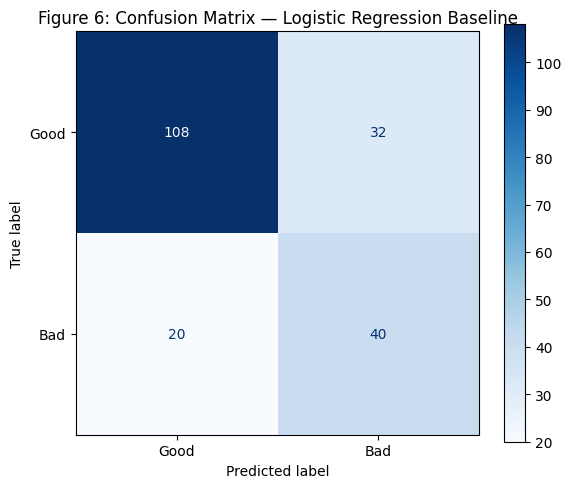

True Negatives (Good→Good):  108
False Positives (Good→Bad):  32
False Negatives (Bad→Good):  20  ← COSTLY (5x penalty)
True Positives (Bad→Bad):    40


In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, display_labels=['Good', 'Bad'],
    cmap='Blues', ax=ax
)
ax.set_title('Figure 6: Confusion Matrix — Logistic Regression Baseline')
plt.tight_layout()
plt.savefig('../shap_plots/lr_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the actual numbers
cm = confusion_matrix(y_test, y_pred_lr)
print(f"True Negatives (Good→Good):  {cm[0][0]}")
print(f"False Positives (Good→Bad):  {cm[0][1]}")
print(f"False Negatives (Bad→Good):  {cm[1][0]}  ← COSTLY (5x penalty)")
print(f"True Positives (Bad→Bad):    {cm[1][1]}")

In [34]:
import joblib

# Save everything for next week's model training
os.makedirs('../models', exist_ok=True)

# Save train/test splits
np.savez('../data/processed/train_test_splits.npz',
         X_train=X_train_smote.values,
         X_test=X_test.values,
         y_train=y_train_smote.values,
         y_test=y_test.values,
         feature_names=X_encoded.columns.tolist())

# Save baseline LR model
joblib.dump(lr, '../models/lr_baseline.pkl')

# Save label encoders for later use
joblib.dump(le_dict, '../models/label_encoders.pkl')

print("✓ Saved: data/processed/train_test_splits.npz")
print("✓ Saved: models/lr_baseline.pkl")
print("✓ Saved: models/label_encoders.pkl")
print("\nReady for Week 5 — XGBoost, LightGBM, Random Forest training")

✓ Saved: data/processed/train_test_splits.npz
✓ Saved: models/lr_baseline.pkl
✓ Saved: models/label_encoders.pkl

Ready for Week 5 — XGBoost, LightGBM, Random Forest training
